# Exploratory Data Analysis (EDA) - Housing Dataset
## Kunskapskontroll 3

I denna notebook genomför jag en utforskande analys av housing-datasetet.

## 1. Initera python bibliotek och skriva ut lite information om tabellen

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('muted')

%matplotlib inline

df = pd.read_csv('housing.csv')

print("Info")
print(df.shape)
print(f"Row: {df.shape[0]}")
print(f"Cols: {df.shape[1]}")

display(df.head(10))
df.info()



Info
(20640, 10)
Row: 20640
Cols: 10


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


***NOTE: Total bedrooms, känns märklig hög, men misstänker det handlar om generell data(?), totalen på alla hushåll och inte individuella hus.

## 2. Statistik med describe, för översikt

In [28]:
remove_columns = ["longitude","latitude"]
df.drop(columns=remove_columns).describe()



,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 3. Städa datan undersöka vad som saknas 


In [29]:
missing_values = df.isnull().sum()
# Kontrollera saknade värden
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({
    'Antal saknade': missing_values,
    'Procent': missing_percentage
})

print("Saknade värden per kolumn:")
print(missing_data[missing_data['Antal saknade'] > 0])
#Vi vet sedan förut att det saknas total_bedrooms
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

print(f"Saknade värden efter fixning: {df['total_bedrooms'].isnull().sum()}")



Saknade värden per kolumn:
                Antal saknade   Procent
total_bedrooms            207  1.002907
Saknade värden efter fixning: 0


## 4. ocean_proximity är ett objekt, vi försöker normalisera den en aning

In [30]:
ocean_map = {'INLAND': 0, 'NEAR BAY': 1, 'NEAR OCEAN': 2, '<1H OCEAN': 3}
df['ocean_proximity_num'] = df['ocean_proximity'].map(ocean_map)
df.info()
display(df.head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   longitude            20640 non-null  float64
 1   latitude             20640 non-null  float64
 2   housing_median_age   20640 non-null  float64
 3   total_rooms          20640 non-null  float64
 4   total_bedrooms       20640 non-null  float64
 5   population           20640 non-null  float64
 6   households           20640 non-null  float64
 7   median_income        20640 non-null  float64
 8   median_house_value   20640 non-null  float64
 9   ocean_proximity      20640 non-null  object 
 10  ocean_proximity_num  20635 non-null  float64
dtypes: float64(10), object(1)
memory usage: 1.7+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_num
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,1.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,1.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,1.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,1.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,1.0
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY,1.0
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY,1.0
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY,1.0
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY,1.0
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY,1.0


## 5. Sovrum/kontra rum

In [31]:
df['bedroom_ratio'] = df['total_bedrooms'] / df['total_rooms']
df["bedroom_per_household"] = df['total_bedrooms'] / df['households'] 
print(f"Sovrum: {df['total_bedrooms'].mean():.2%}") #hittade en ny syntax grej för formatering
print(f"Totalt antal rum {df['total_rooms'].mean():.2%}")

print(f"Medel: {df['bedroom_ratio'].mean():.2%}")
print(f"Median: {df['bedroom_ratio'].median():.2%}")
print()
print(f"Sovrum per hushåll: {df['bedroom_per_household'].median():.2f}")

#TODO; validera så vinte får 0 värden på total bedrooms etc

#TODO: Vi vill ha fram relatione mellan inkomst och antal sovrum 
# df['test'] = df['median_income'].max()/df['total_bedrooms']
#df['test'].mean()


Sovrum: 53683.89%
Totalt antal rum 263576.31%
Medel: 21.38%
Median: 20.32%

Sovrum per hushåll: 1.05


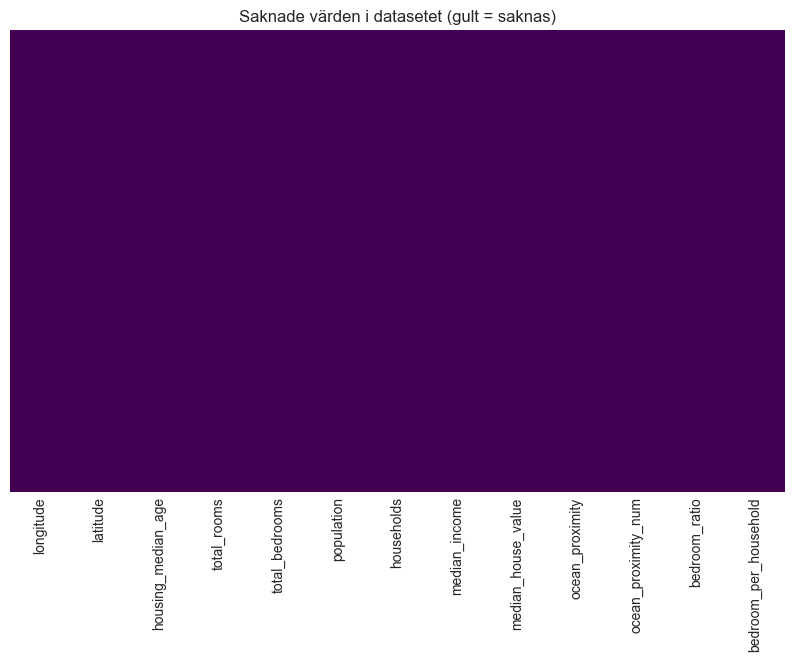

In [32]:

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Saknade värden i datasetet (gult = saknas)')
plt.show()

**Note:** ~~Om det finns saknade värden i bedrom_ratio (tror jag), bedroom_per_household? Dessa borde vi kunna fylla med medianer;men vi ska inte använda denna datan så vi lämnar den nu.~~ Fel i min ursprungliga data, inga saknade hittades

## 7. Målvariabler

Försöka förstå vad det är som tex påverkar huspriser

In [33]:
# Grundläggande statistik för huspriserna
print("Statistik för median_house_value:")
print(f"Medel ${df['median_house_value'].mean():,.0f}")
print(f"Median: ${df['median_house_value'].median():,.0f}")
print(f"Min: ${df['median_house_value'].min():,.0f}")
print(f"Max: ${df['median_house_value'].max():,.0f}")


Statistik för median_house_value:
Medel $206,856
Median: $179,700
Min: $14,999
Max: $500,001


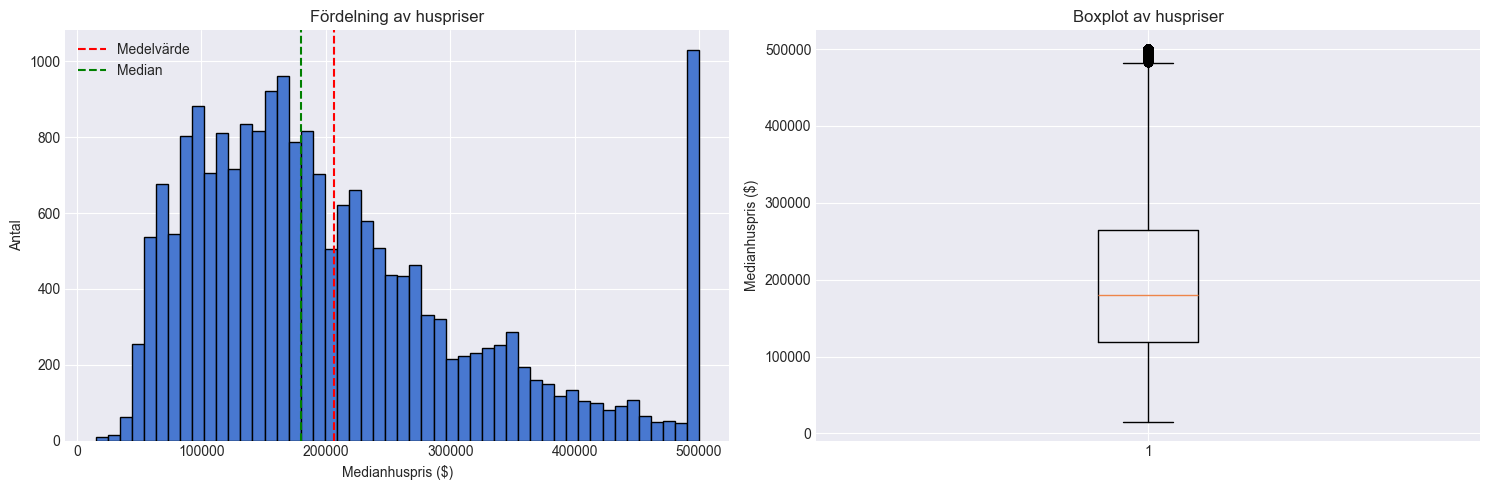

In [34]:
#https://www.youtube.com/watch?v=qlYVdALN1bk
# Här går jag bet; Claude stöttar upp
fig, ax = plt.subplots(1, 2, )
fig.set_size_inches(15,5)
# Histogram
ax[0].hist(df['median_house_value'], bins=50, edgecolor='black')
ax[0].set_xlabel('Medianhuspris ($)')
ax[0].set_ylabel('Antal')
ax[0].set_title('Fördelning av huspriser')
ax[0].axvline(df['median_house_value'].mean(), color='red', linestyle='--', label='Medelvärde')
ax[0].axvline(df['median_house_value'].median(), color='green', linestyle='--', label='Median')
ax[0].legend()

# Boxplot, vet inte vad detta represnterar
ax[1].boxplot(df['median_house_value'])
ax[1].set_ylabel('Medianhuspris ($)')
ax[1].set_title('Boxplot av huspriser')

plt.tight_layout()
plt.show()

## 8. Geografi

Har genom att tagit ut longitude och latitude, kommit fram till att vi är i kalifornien.

Lat/Long 35.63186143410852,-119.56970445736432
Graf 8.1


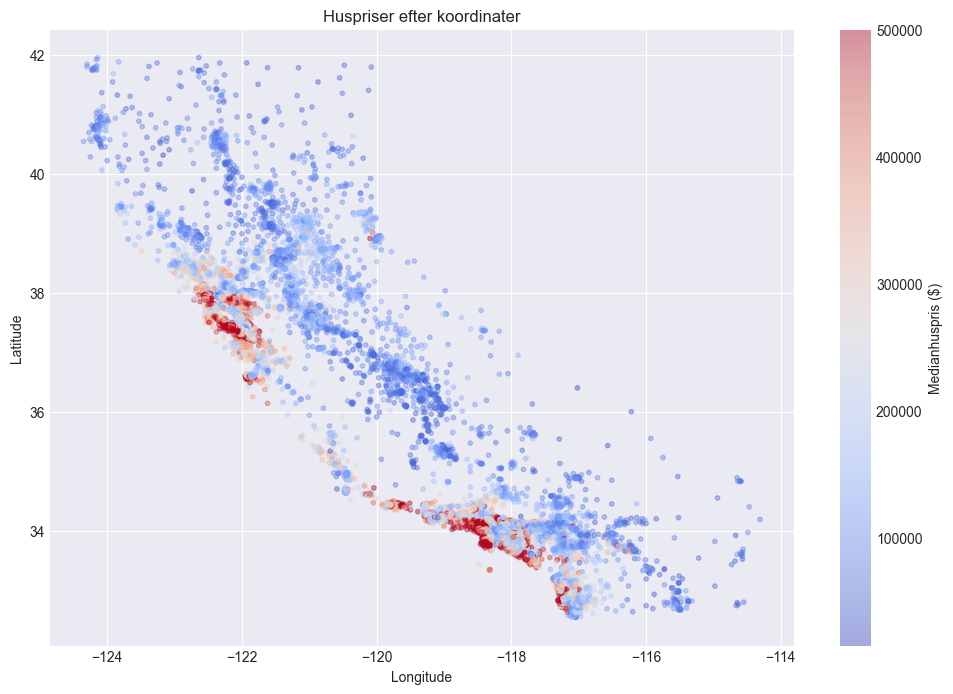


**Observation:** Denna karta visar var dyra vs billiga hus ligger geografiskt.


In [35]:
long = df["longitude"].mean()
lat = df["latitude"].mean()

print(f"Lat/Long {lat},{long}") ##google maps säger kalifornien

#Karta var svår.. google + hamnade på fel matlib så till slut bollade jag med ai/claude. eller..den fick korrigera min kod.
#TODO: Lägg till karta hade varit najs
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['longitude'], df['latitude'], 
                     c=df['median_house_value'], 
                     cmap='coolwarm', 
                     alpha=0.4, 
                     s=10)
plt.colorbar(scatter, label='Medianhuspris ($)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Huspriser efter koordinater')
print("Graf 8.1")
plt.show()

print("\n**Observation:** Denna karta visar var dyra vs billiga hus ligger geografiskt.")

## 9. Priser jämfört med placering av huset med höjd över havet

Vi använder en tredjepartstjänst här, pga begränsiningar i gratis api, vi siktar bara på de första 100.

Hämtat 10 av 100...
Hämtat 20 av 100...
Hämtat 30 av 100...
Hämtat 40 av 100...
Hämtat 50 av 100...
Hämtat 60 av 100...
Hämtat 70 av 100...
Hämtat 80 av 100...
Hämtat 90 av 100...
Hämtat 100 av 100...
Graf 9.1


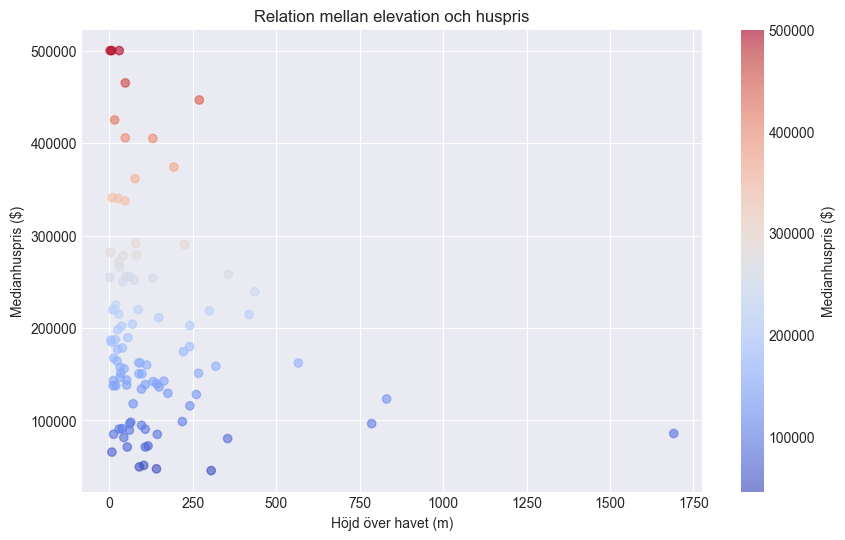

Korrelation mellan elevation och pris: -0.190


In [36]:
import requests
import time

# Funktion för att hämta elevation
def get_elevation(lat, lon):
    try:
        url = f"https://api.opentopodata.org/v1/ned10m?locations={lat},{lon}"
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            return data['results'][0]['elevation']
        else:
            return np.nan
    except:
        return np.nan

# Hämta elevation för ett sample (för att testa först)
# OBS: API har rate limit, så testa med ett litet sample först!
sample_size = 100  # Börja med 100 rader
df_sample = df.sample(n=sample_size, random_state=42)

# Skapa en ny kolumn för elevation
elevations = []
for idx, row in df_sample.iterrows():
    elevation = get_elevation(row['latitude'], row['longitude'])
    elevations.append(elevation)
    time.sleep(0.1)  # Vänta lite mellan requests för att respektera rate limit
    
    if len(elevations) % 10 == 0:
        print(f"Hämtat {len(elevations)} av {sample_size}...")

df_sample['elevation'] = elevations


print("Graf 9.1")
plt.figure(figsize=(10, 6))
plt.scatter(df_sample['elevation'], df_sample['median_house_value'], 
            alpha=0.6, c=df_sample['median_house_value'], cmap='coolwarm')
plt.xlabel('Höjd över havet (m)')
plt.ylabel('Medianhuspris ($)')
plt.title('Relation mellan elevation och huspris')
plt.colorbar(label='Medianhuspris ($)')

plt.show()


correlation = df_sample['elevation'].corr(df_sample['median_house_value'])
print(f"Korrelation mellan elevation och pris: {correlation:.3f}")

##  10. Närhet till havet

Hur påverkar närhet till havet, priserna.

ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Genomsnittpris per ocean_proximity:
ocean_proximity
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
<1H OCEAN     240084.285464
INLAND        124805.392001
Name: median_house_value, dtype: float64

Graf 10.1


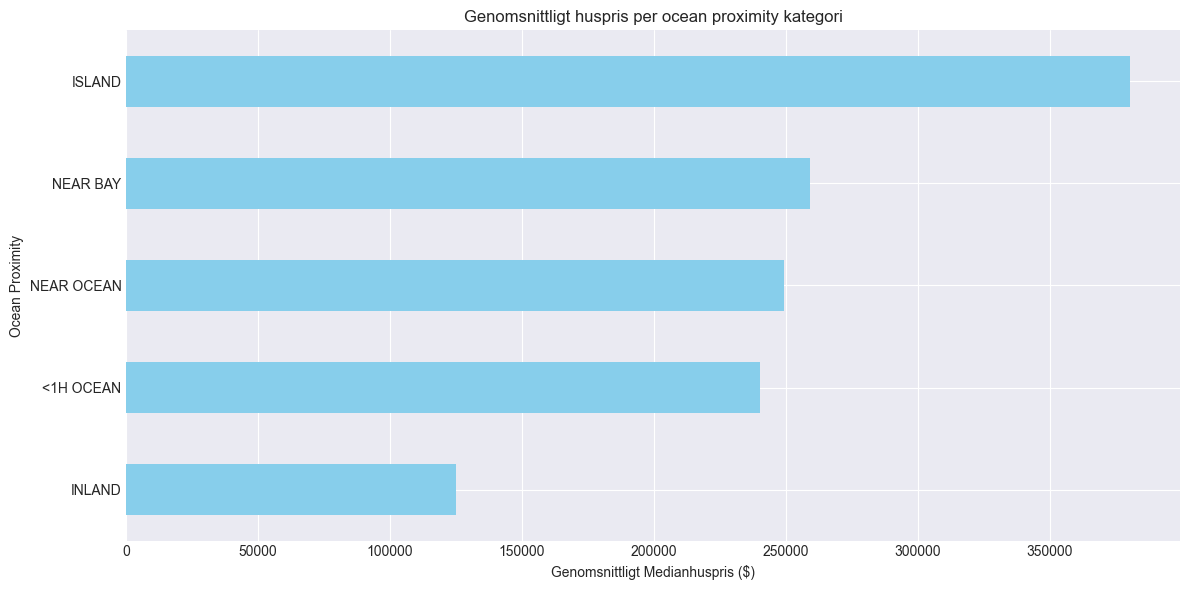


Antal hus per kategori:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Medelpris per kategori:
ocean_proximity
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
<1H OCEAN     240084.285464
INLAND        124805.392001
Name: median_house_value, dtype: float64


In [37]:
print("ocean_proximity:")
print(df['ocean_proximity'].value_counts())
print()

avg_price_by_ocean = df.groupby('ocean_proximity')['median_house_value'].mean().sort_values(ascending=False)
print("\nGenomsnittpris per ocean_proximity:")
print(avg_price_by_ocean)

print()
plt.figure(figsize=(12, 6))
df.groupby('ocean_proximity')['median_house_value'].mean().sort_values().plot(kind='barh', color='skyblue')
plt.xlabel('Genomsnittligt Medianhuspris ($)')
plt.ylabel('Ocean Proximity')
plt.title('Genomsnittligt huspris per ocean proximity kategori')
plt.tight_layout()
print("Graf 10.1")
plt.show()

# Visa även antal i varje kategori
print("\nAntal hus per kategori:")
print(df['ocean_proximity'].value_counts())
print("\nMedelpris per kategori:")
print(df.groupby('ocean_proximity')['median_house_value'].mean().sort_values(ascending=False))

## 11. Inkomster relativt till priser 


Graf 11.1


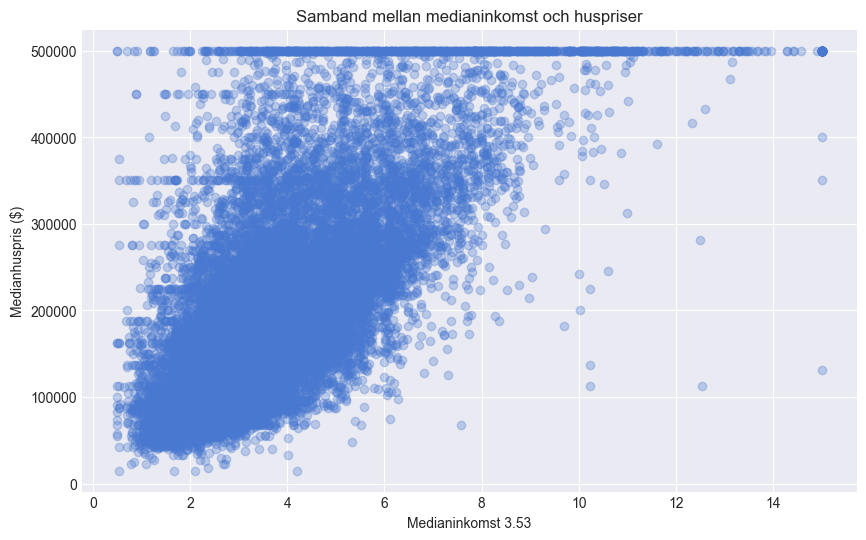

In [38]:
# Enligt sökning så är scatter plot för detta.. svår att läsa men...
plt.figure(figsize=(10, 6))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.3)
plt.xlabel(f"Medianinkomst {df['median_income'].median():.2f}")
plt.ylabel('Medianhuspris ($)')
plt.title('Samband mellan medianinkomst och huspriser')
print("Graf 11.1")
plt.show()


Dock, välidgt högt över hela inkomsterna.

## 12. Hus ålder och pris?

Påverkar husets ålder priset?

Graf 12.1


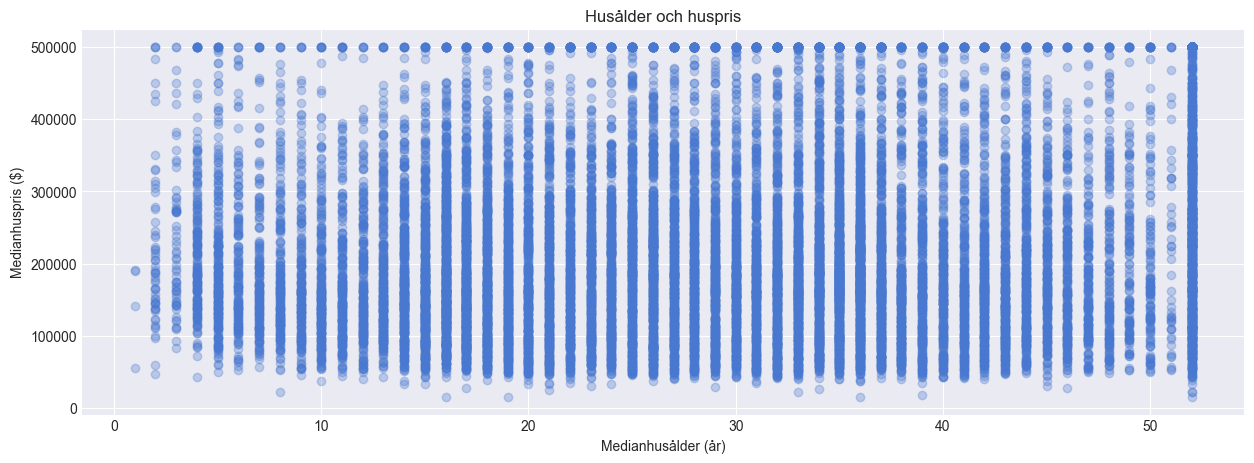

In [39]:
# Scatter plot: housing_median_age vs median_house_value
plt.figure(figsize=(15, 5)) 
plt.scatter(df['housing_median_age'], df['median_house_value'], alpha=0.3)
plt.xlabel('Medianhusålder (år)')
plt.ylabel('Medianhuspris ($)')
plt.title('Husålder och huspris')
print("Graf 12.1")
plt.show()


## 13. Relation mealln avstånd till hav, inkomst och huspriser

Graf 13.1


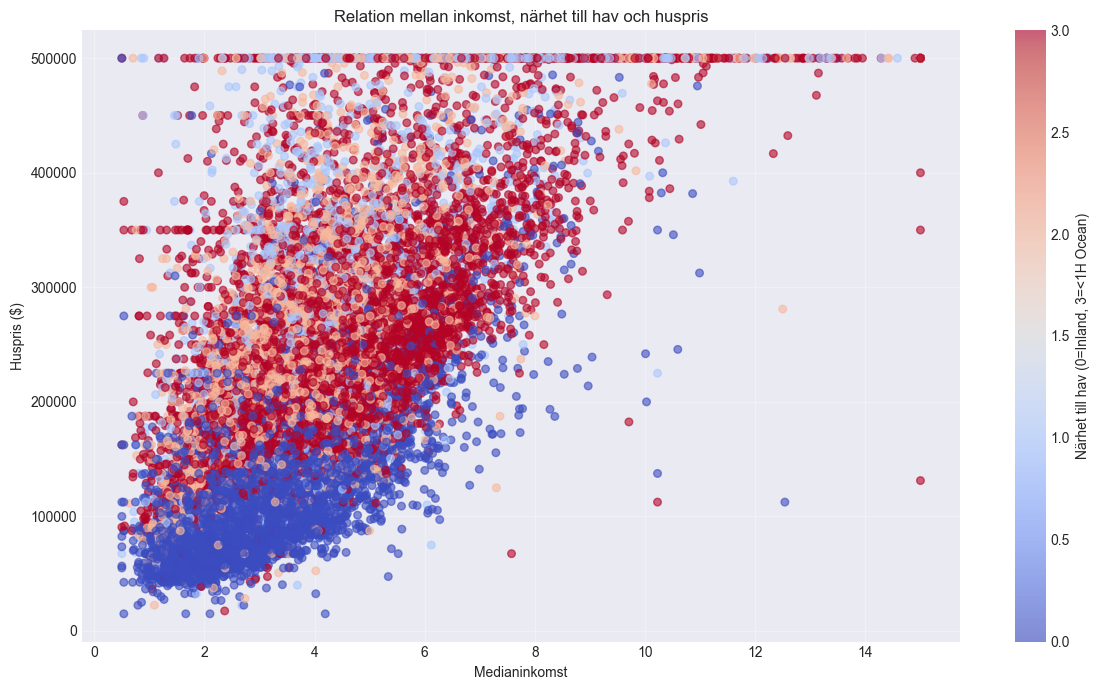

In [40]:
# Scatter plot med färgkodning baserat på närhet till hav
plt.figure(figsize=(12, 7))

scatter = plt.scatter(df['median_income'], 
                     df['median_house_value'],
                     c=df['ocean_proximity_num'],  # Färg = närhet
                     cmap='coolwarm',  # Röd (inland) → Blå (nära hav)
                     alpha=0.6,
                     s=30)

plt.colorbar(scatter, label='Närhet till hav (0=Inland, 3=<1H Ocean)')
plt.xlabel('Medianinkomst')
plt.ylabel('Huspris ($)')
plt.title('Relation mellan inkomst, närhet till hav och huspris')
plt.grid(True, alpha=0.3)
plt.tight_layout()
print("Graf 13.1")
plt.show()

Inkomst har stor påverkan på priset

## 14. Feature engineering möjligheter

Skapa nya variabler för att hitta nya möjligheter. (inte 100% koll vad detta innebär, läste det var end el av EDA)

In [41]:
# Skapa nya features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

print("Nya features skapade:")
print("- rooms_per_household")
print("- bedrooms_per_room")
print("- population_per_household")

Nya features skapade:
- rooms_per_household
- bedrooms_per_room
- population_per_household


In [42]:
# Kolla korrelation för de nya features
new_features = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
new_correlations = df[new_features + ['median_house_value']].corr()['median_house_value'].sort_values(ascending=False)

print("Korrelation mellan nya features och huspris:")
print(new_correlations)

Korrelation mellan nya features och huspris:
median_house_value          1.000000
rooms_per_household         0.151948
population_per_household   -0.023737
bedrooms_per_room          -0.233303
Name: median_house_value, dtype: float64


##  15. Hitta outliners


Sök ovanliga värden som kan påverka medianen

=== median_house_value (IQR) ===
Q1: 119600.00, Q3: 264725.00, IQR: 145125.00
Lower: -98087.50, Upper: 482412.50
Antal outliers: 1071 (5.19%)
Graf 15.1


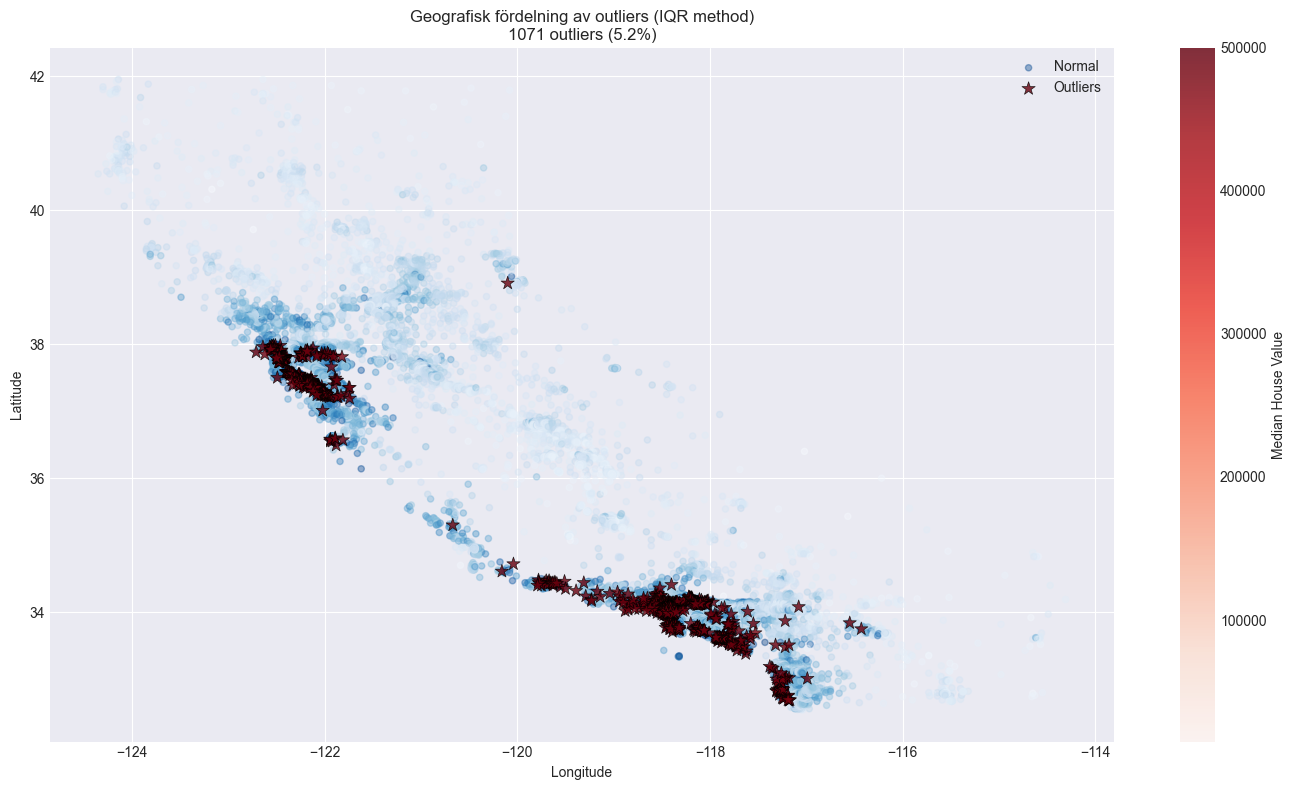


Normal hus (mean): $190852.30
Outlier hus (mean): $499267.38

Ocean proximity fördelning för outliers:
ocean_proximity
<1H OCEAN     584
NEAR OCEAN    239
NEAR BAY      216
INLAND         32
Name: count, dtype: int64


In [43]:

def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"=== {column} (IQR) ===")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Lower: {lower_bound:.2f}, Upper: {upper_bound:.2f}")
    print(f"Antal outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    
    return outliers, lower_bound, upper_bound


# Använd IQR för att hitta outliers
outliers_iqr, lower, upper = find_outliers_iqr(df, 'median_house_value')

# Visualisera dem geografiskt
plt.figure(figsize=(14, 8))

# Normal hus
normal = df[~df.index.isin(outliers_iqr.index)]
plt.scatter(normal['longitude'], normal['latitude'], 
            c=normal['median_house_value'], cmap='Blues',
            alpha=0.4, s=20, label='Normal', vmin=df['median_house_value'].min(), 
            vmax=df['median_house_value'].max())

# Outliers
plt.scatter(outliers_iqr['longitude'], outliers_iqr['latitude'],
            c=outliers_iqr['median_house_value'], cmap='Reds',
            alpha=0.8, s=100, marker='*', edgecolors='black', linewidth=0.5,
            label='Outliers', vmin=df['median_house_value'].min(), 
            vmax=df['median_house_value'].max())

plt.colorbar(label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Geografisk fördelning av outliers (IQR method)\n{len(outliers_iqr)} outliers ({len(outliers_iqr)/len(df)*100:.1f}%)')
plt.legend()
plt.tight_layout()
print("Graf 15.1")
plt.show()

# Analysera outliers
print(f"\nNormal hus (mean): ${normal['median_house_value'].mean():.2f}")
print(f"Outlier hus (mean): ${outliers_iqr['median_house_value'].mean():.2f}")
print(f"\nOcean proximity fördelning för outliers:")
print(outliers_iqr['ocean_proximity'].value_counts())

Q1 (25%): $119,600
Q3 (75%): $264,725
IQR: $145,125
Lower bound: $-98,088
Upper bound: $482,412

Antal outliers: 1071 (5.2%)
Graf 15.2


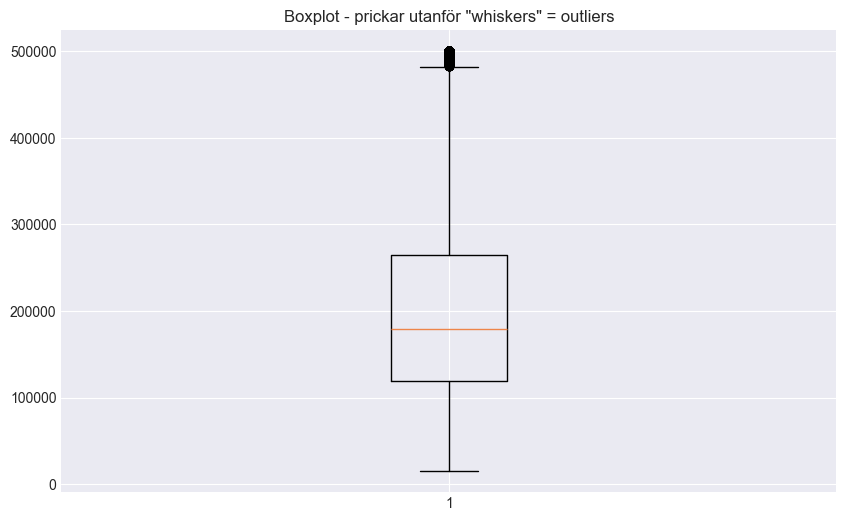

In [44]:
# Beräkna IQR (Interquartile Range)
Q1 = df['median_house_value'].quantile(0.25)
Q3 = df['median_house_value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25%): ${Q1:,.0f}")
print(f"Q3 (75%): ${Q3:,.0f}")
print(f"IQR: ${IQR:,.0f}")
print(f"Lower bound: ${lower_bound:,.0f}")
print(f"Upper bound: ${upper_bound:,.0f}")

# Hitta outliers
outliers = df[(df['median_house_value'] < lower_bound) | 
              (df['median_house_value'] > upper_bound)]

print(f"\nAntal outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
plt.figure(figsize=(10, 6))
plt.boxplot(df['median_house_value'])
plt.title('Boxplot - prickar utanför "whiskers" = outliers')
print("Graf 15.2")
plt.show()

## 16. Sammanfattning av fynd

Slutsatser

### Fynd

1. Inkomst har hög påverkan på huspriset (Grafer 11.1, 13.1)
2. Geografisk placering har påverkan på priset (Grafer 10.1, 13.1)
3. Vissa kolumner saknade värden, fylldes med medianer

Hög medianinkomst gör vissa hus dyrare, viss geografisk placering ger också påverkan beroende på avstånd till hav. 

---

## Självutvärdering

### 1. Har något varit utmanande i kursen/kunskapskontrollerna? Om ja, hur har du hanterat det? Vilka lärdomar tar du med dig till framtida kurser?

Försöka få samman värden i kombination med grafer samt testa vilken graf som passar bäst.
Tidsbrist (personlig brist)
Har använt Claude som AI för stöttning för att försöka förstå relationerna, samt för att diskutera vilka grafer som passar bäst, samt hjälp med beräkningar. 

En hel del svårigheter med greppa hur man ska tänka samt analysera informationen jag får ut av datan. (ovan)

---

### 2. Vilket betyg anser du att du ska ha och varför?

G

Har ju ändå försökt hitta ytterliggheter utifrån den informationen vi har. men jag är alldeles för sent ute så känns slarvit rakt igenom.



---

### 3. Något du vill lyfta fram till Terese?

Tyckte EDA:n var skitsvår (men ändå kul). Här hade jag dock velat ha lite mer lektioner. tankesätt, hur man ska tänka etc.
Jag fastnade lätt på "undrar vilken graf jag ska använda" samt "ok, jag följde någon text om vad jag borde göra, men vad tusan ska använda detta till"